# Porosity Feasibility — Pipeline

Four stages: **EDA** → **baseline (all features + ridge)** → **test-by-test (each
measurement type alone)** → **weighted combination of all tests, validated honestly**.

Every modeling result is checked against a constant baseline under **both** 5-fold and
leave-one-out (LOO) cross-validation -- comparing the two schemes is a check on
sensitivity to the train/holdout partition. With only n=20 samples, this notebook's
adopted standard is to treat a result that only beats baseline under one scheme with
skepticism -- consistent with one fold happening to go its way -- rather than to report
it as established.


In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA = Path("data")

# Helper: render a saved Plotly HTML figure to a PNG and embed it directly as this
# cell's own output (no external file dependency -- self-contained in the .ipynb).
# Runs the browser in a subprocess to avoid any asyncio conflict with the Jupyter kernel.
import subprocess
import os
import sys
import tempfile
from IPython.display import Image, display

def show_figure_as_image(html_path, width=1250, height=850, enable_screenshot=True):
    """Optional: embed a static PNG snapshot of the interactive Plotly HTML as cell output.
    Requires Playwright with a Chromium browser; skips gracefully (prints a notice) if
    unavailable, rather than failing the notebook run. The standalone interactive .html
    file referenced by html_path is always produced regardless of this step -- open it
    directly in a browser if the embedded screenshot isn't shown."""
    if not enable_screenshot:
        print(f"(screenshot capture disabled -- open {html_path} directly for the interactive figure)")
        return
    abs_path = os.path.abspath(html_path)
    out_path = os.path.join(tempfile.gettempdir(), f"_nb_fig_{os.getpid()}.png")
    candidate_chromium = os.environ.get("PLAYWRIGHT_CHROMIUM_PATH", "/opt/pw-browsers/chromium")
    script = (
        "import os\n"
        "from playwright.sync_api import sync_playwright\n"
        "with sync_playwright() as p:\n"
        f"    candidate = {candidate_chromium!r}\n"
        "    kwargs = {'executable_path': candidate} if os.path.exists(candidate) else {}\n"
        "    browser = p.chromium.launch(**kwargs)\n"
        f"    page = browser.new_page(viewport={{'width': {width}, 'height': {height}}})\n"
        f"    page.goto('file://{abs_path}')\n"
        "    page.wait_for_timeout(1200)\n"
        f"    page.screenshot(path={out_path!r}, full_page=True)\n"
        "    browser.close()\n"
    )
    try:
        result = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True, timeout=60)
        if result.returncode != 0 or not os.path.exists(out_path):
            err = (result.stderr or "unknown error")[-300:]
            print(f"(screenshot capture unavailable -- Playwright/Chromium not found or failed "
                  f"({err}); open {html_path} directly for the interactive figure)")
            return
        with open(out_path, "rb") as f:
            display(Image(data=f.read()))
    except Exception as e:
        print(f"(screenshot capture unavailable ({e}); open {html_path} directly for the interactive figure)")


## Customer clarifications, assumptions, and scope

**Customer clarifications actually received, stated precisely:**
- *Measurement locations:* Christina stated that the 100 repeat measurements per sample
  are taken at different physical locations on that sample, not time-ordered or repeated
  scans of one spot. The specific locations themselves are not relevant to this exercise.
- *Independence:* following Christina's guidance, samples are assumed independently
  prepared for this exercise. Their preparation history has not been independently
  verified here -- this is a stated working assumption, not a confirmed experimental
  fact, and it's what the 5-fold/LOO sample-level cross-validation in this notebook
  relies on.

**A choice made in this analysis, not a customer requirement:**
- *Sample representation:* mean aggregation (averaging each sample's 100 repeat readings
  into one feature vector) is the representation used throughout this notebook. It may
  discard useful variation across locations -- Christina confirmed the locations differ,
  not that averaging across them is the right way to summarize that. This notebook
  doesn't establish that mean aggregation is optimal, only that it's a reasonable,
  simple starting point (Section 1).

**Assumed, not confirmed -- and why it doesn't block this analysis:**
- *Reference matching:* porosity is linked to sensor data by `sample_id` only. The
  reference porosity measurement's method, timing, and spatial relationship to what the
  sensors captured are unconfirmed -- a possible source of irreducible noise in every
  result in this notebook that hasn't been separately quantified.
- The `V_t`/`I_t` column suffix (`_0..511`) is treated as a within-measurement time
  index. No timestamp column confirms this; it's inferred from the smooth, periodic
  waveform shape and from voltage and current being synchronized at the same period
  (independently measured quantities agreeing on a shared periodic structure is strong
  circumstantial evidence for a real time axis, even without a labeled unit).
- `OES_bin` -> wavelength (nm) mapping was independently verified against the provided
  wavelength file (column order, sequential bin numbers, uniform ~3.53nm spacing) -- this
  one is confirmed, not assumed.
- *Thermal values:* `IR_pix` values are treated as recorded detector measurements, not
  silently relabeled as calibrated temperature. This notebook does **not** confirm they
  are calibrated temperature as opposed to raw, uncalibrated intensity counts. Section 6's
  physical hypothesis assumes they track real surface heat -- reasonable, but unverified
  here, and worth confirming before presenting the mechanism as more than a hypothesis.
- *Thermal geometry:* `IR_pix`'s 1,024-pixel spatial layout -- dimensions, ordering,
  orientation, and physical interpretation -- is **not known** from any metadata in the
  provided data. This does not block the predictive result (ridge uses the pixels as an
  unordered feature vector, not a 2D image), but it is the specific reason the winning
  model cannot currently be explained in terms of *which region* of the thermal image
  matters. The companion notebook plots a candidate 32x32 layout because it fits the
  data's clustering pattern best among alternatives tried -- that is a plotted assumption
  for visualization, not confirmed sensor metadata, and its figures say so explicitly.
- *Thickness:* the sensor models reproduced in this notebook (Sections 4, 5, 7, 8, 9)
  **exclude thickness** as a predictor -- it appears only in the EDA table (Section 1)
  and the standalone `thickness_effect.html` figure, which is a separate, smaller check
  outside this notebook's main stages, not part of Sections 4-9's feature sets.
- *Data quality:* no records were excluded from any pass -- an executed data-quality
  audit (duplicate rows, missing values, repeat counts per sample, all checked in Section
  1/2) found no defect that would justify dropping a sample. A successful join between
  the measurement and porosity tables by `sample_id` is not, by itself, evidence that the
  porosity label is physically correct for that sample -- see *Reference matching* above.

**The customer's accuracy target, precisely:**
- The "<=1% prediction error" goal remains ambiguous: it could mean an average absolute
  error (MAE, in porosity's own units -- percentage points, since porosity is reported as
  a percentage), an average relative error (MAPE, an average of sample-level absolute
  relative errors, displayed as a percentage), or an individual-prediction tolerance (no
  prediction more than 1% off). This notebook reports MAE and MAPE separately throughout
  and does not assume a per-prediction acceptance criterion -- an average error of one
  percentage point does not imply every single prediction lands within one percentage
  point of the true value, and MAPE is not derived by dividing MAE by average porosity
  (they're computed independently, from different formulas).
- Under either the MAE or MAPE reading, the full-pixel thermal reference model's results
  fall short: **LOO MAE 2.02** (roughly 2x an MAE=1.0 reading of the target) and **LOO
  MAPE 7.7%** (roughly 7.7x a MAPE<=1% reading of the target), against the LOO baseline of
  MAE 2.50 / MAPE 9.9%. The matching 5-fold numbers are MAE 2.27 / MAPE 8.8%, against a
  5-fold baseline of MAE 2.45 / MAPE 9.7% -- five-fold results are compared to the
  five-fold baseline, LOO to the LOO baseline, not mixed across schemes. Section 7's
  exploratory pixel-restriction sweep suggests LOO MAPE as low as ~7.4-7.5% may be
  achievable, but that number isn't independently validated (Section 7's own caveats).
- Whether sample thickness would actually be available before a real prediction is
  needed, in the production workflow, is unconfirmed and would determine whether the
  separate thickness check above is even a usable option in practice.

**Scope boundary:** this notebook reproduces the techniques and results that materially
inform the final conclusion. A substantially broader set of exploratory techniques was
tried in the process (additional feature-selection and combination methods, alternative
preprocessing choices, alternative training strategies) -- see the AI-use disclosure in
`README.md` for how that exploration relates to what's reproduced here. None of that
broader exploration changed the conclusion in this notebook; it's summarized, not
re-derived, for the reasons given there. The companion notebook,
`porosity_explainability_attempt.ipynb`, shares these same assumptions and is not
re-stated there -- see its introduction for a short pointer back to this section.

## 1. Load and aggregate data

In [2]:
sample_info = pd.read_csv(DATA / "Sample_Info.csv", index_col=0)
measurement_parts = [
    "Measurement_Data_part_1_samples_0-6.csv",
    "Measurement_Data_part_2_samples_7-13.csv",
    "Measurement_Data_part_3_samples_14-19.csv",
]
meas = pd.concat([pd.read_csv(DATA / fn, index_col=0) for fn in measurement_parts], ignore_index=True)
oes_wavelengths = pd.read_csv(DATA / "OES_Wavelengths.csv", index_col=0)

feat_cols = [c for c in meas.columns if c not in ("sample_id", "measurement_id")]
oes_cols = [c for c in feat_cols if c.startswith("OES_bin")]
vt_cols = [c for c in feat_cols if c.startswith("V_t")]
it_cols = [c for c in feat_cols if c.startswith("I_t")]
ir_cols = [c for c in feat_cols if c.startswith("IR_pix")]

# Aggregate to sample level: mean over each sample's 100 repeat measurements
# (justified -- the repeats are different physical locations, not time-ordered,
# so a bulk sample-level property like porosity should map to their average)
grp = meas.groupby("sample_id")
sample_feats = grp[feat_cols].mean().reset_index()
data = sample_info.merge(sample_feats, on="sample_id", how="left").sort_values("sample_id").reset_index(drop=True)

y = data["porosity"].values
sample_ids = data["sample_id"].values
print(f"sample-level table: {data.shape}  (20 samples x {len(feat_cols)} sensor features + porosity + thickness)")
data[["sample_id", "thickness", "porosity"]]


sample-level table: (20, 2307)  (20 samples x 2304 sensor features + porosity + thickness)


,sample_id,thickness,porosity
0,0,92.17,27.36
1,1,70.68,26.89
2,2,83.67,20.26
3,3,93.86,28.91
4,4,92.64,31.02
5,5,66.23,28.34
6,6,85.75,26.24
7,7,75.73,28.55
8,8,78.25,25.95
9,9,68.24,19.96


## 2. EDA — all 4 measurement types, per sample

Interactive Plotly version saved to `eda_measurements_by_sample.html` (open it for
hover/zoom/legend-isolate). Static preview below for portability -- GitHub's notebook
viewer doesn't execute the JS Plotly needs to render interactively inline.


saved eda_measurements_by_sample.html


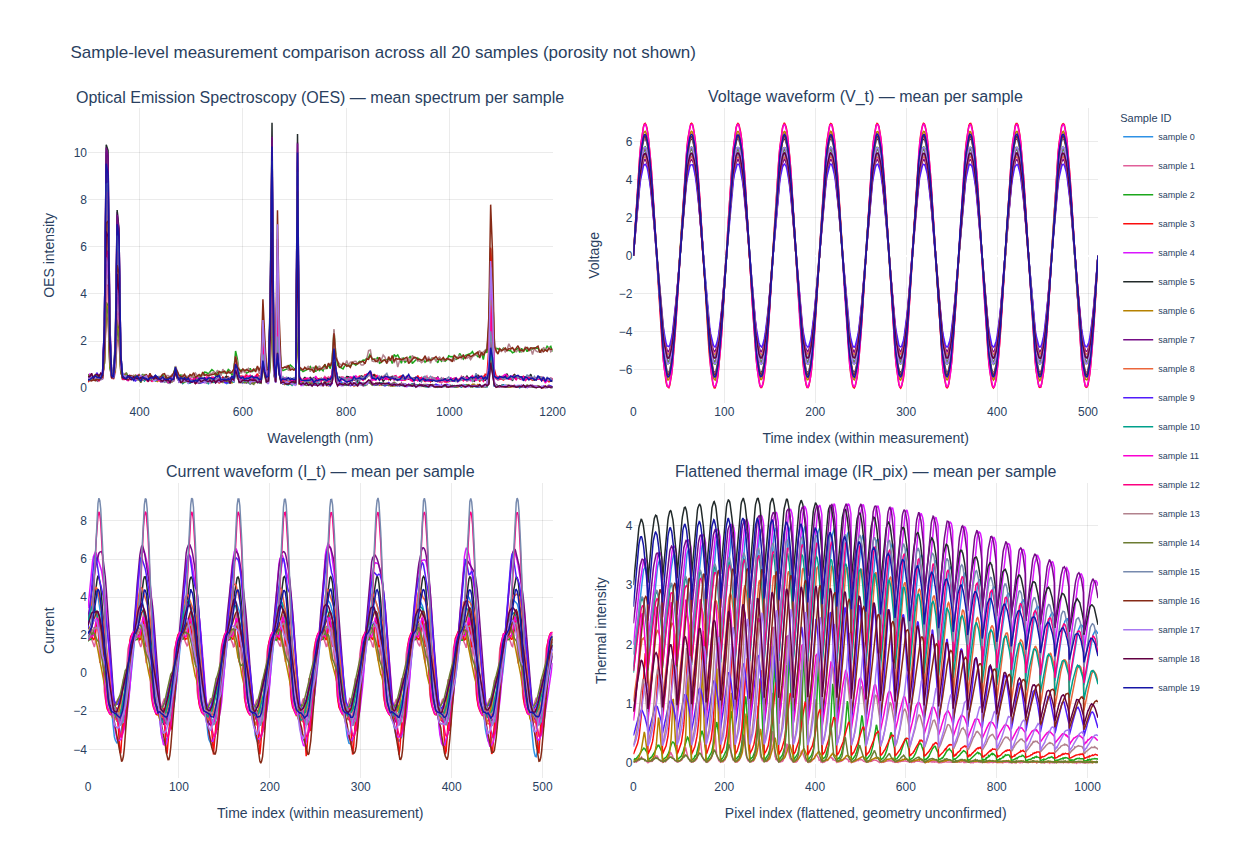

In [3]:
QUAL = pc.qualitative.Dark24
def sample_color(i):
    return QUAL[i % len(QUAL)]

fig_eda = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Optical Emission Spectroscopy (OES) — mean spectrum per sample",
        "Voltage waveform (V_t) — mean per sample",
        "Current waveform (I_t) — mean per sample",
        "Flattened thermal image (IR_pix) — mean per sample",
    ),
    horizontal_spacing=0.08, vertical_spacing=0.12,
)
panel_specs = [
    (oes_cols, oes_wavelengths["Wavelength (nm)"].values, "Wavelength (nm)", "OES intensity", 1, 1),
    (vt_cols, np.arange(len(vt_cols)), "Time index (within measurement)", "Voltage", 1, 2),
    (it_cols, np.arange(len(it_cols)), "Time index (within measurement)", "Current", 2, 1),
    (ir_cols, np.arange(len(ir_cols)), "Pixel index (flattened, geometry unconfirmed)", "Thermal intensity", 2, 2),
]
for cols, x_vals, x_title, y_title, row, col in panel_specs:
    for i, sid in enumerate(sample_ids):
        y_vals = data.loc[data["sample_id"] == sid, cols].values.flatten()
        fig_eda.add_trace(
            go.Scatter(x=x_vals, y=y_vals, mode="lines", line=dict(color=sample_color(i), width=1.5),
                       name=f"sample {int(sid)}", legendgroup=f"sample {int(sid)}",
                       showlegend=(row == 1 and col == 1),
                       hovertemplate=f"sample {int(sid)}<br>x=%{{x}}<br>y=%{{y:.3f}}<extra></extra>"),
            row=row, col=col,
        )
    fig_eda.update_xaxes(title_text=x_title, row=row, col=col, showgrid=True, gridcolor="rgba(0,0,0,0.08)")
    fig_eda.update_yaxes(title_text=y_title, row=row, col=col, showgrid=True, gridcolor="rgba(0,0,0,0.08)")

fig_eda.update_layout(
    title="Sample-level measurement comparison across all 20 samples (porosity not shown)",
    height=850, width=1250, legend=dict(title="Sample ID", x=1.02, y=1, font=dict(size=9)),
    plot_bgcolor="white", paper_bgcolor="white", margin=dict(r=160),
)
fig_eda.write_html("eda_measurements_by_sample.html", include_plotlyjs=True)
print("saved eda_measurements_by_sample.html")
show_figure_as_image("eda_measurements_by_sample.html")


No missing values, no duplicate rows, every sample has exactly 100 repeats. OES shows
sharp, well-defined emission peaks; voltage is a clean, near-periodic oscillation;
current is visibly distorted/asymmetric (a nonlinear response, not just a phase-shifted
copy of voltage); thermal shows clear banding/separation between samples -- the most
visually distinct panel, foreshadowing Section 4's finding.


## 3. Modeling framework

Every model is compared against a **mean baseline** (predict the training-fold average
porosity) under **5-fold** and **leave-one-out (LOO)** cross-validation. Scaling and any
hyperparameter search happen inside each training fold only -- never on the held-out
point. Ridge is run **unstandardized**, per a direct standardized-vs-unstandardized check
(ridge does marginally better unstandardized on this data; PCR does better standardized --
noted for completeness, not used further here since ridge is the model that matters).

**Tuning objective:** `RidgeCV(cv=None)` selects its regularization strength using
efficient internal leave-one-out mean squared error (the library default). Final
performance below is reported using MAE and MAPE -- the ridge penalty itself was not
optimized directly for either of those reported metrics.


In [4]:
def make_cv(scheme):
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if scheme == "five_fold" else LeaveOneOut()

def mape(y_true, y_pred):
    return np.mean(np.abs((y_pred - y_true) / y_true)) * 100

def evaluate_ridge(X, y, scheme):
    n = len(y)
    cv = make_cv(scheme)
    preds = np.zeros(n)
    alphas = np.logspace(-2, 5, 40)
    for train_idx, test_idx in cv.split(X):
        model = RidgeCV(alphas=alphas, cv=None)  # unstandardized; internal LOO alpha search on the training fold
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])
    return mean_absolute_error(y, preds), mape(y, preds), preds

def evaluate_baseline(y, scheme):
    n = len(y)
    cv = make_cv(scheme)
    preds = np.zeros(n)
    for train_idx, test_idx in cv.split(np.zeros(n)):
        preds[test_idx] = y[train_idx].mean()
    return mean_absolute_error(y, preds), mape(y, preds), preds

baseline_results = {s: evaluate_baseline(y, s) for s in ["five_fold", "loo"]}
for s, (mae, mp, _) in baseline_results.items():
    print(f"baseline  {s:10s}  MAE={mae:.3f}  MAPE={mp:.2f}%")


baseline  five_fold   MAE=2.445  MAPE=9.70%
baseline  loo         MAE=2.503  MAPE=9.91%


## 4. Stage 1 — Baseline model: all 2,304 features + ridge

The direct approach: throw every sensor feature at ridge and see if it beats guessing
the average.


In [5]:
X_all = data[feat_cols].values
stage1_rows = []
for scheme in ["five_fold", "loo"]:
    mae, mp, _ = evaluate_ridge(X_all, y, scheme)
    base_mae = baseline_results[scheme][0]
    stage1_rows.append({"scheme": scheme, "MAE": round(mae, 3), "MAPE": round(mp, 2),
                         "baseline_MAE": round(base_mae, 3), "beats_baseline": mae < base_mae})
pd.DataFrame(stage1_rows)


,scheme,MAE,MAPE,baseline_MAE,beats_baseline
0,five_fold,2.404,9.37,2.445,True
1,loo,2.197,8.56,2.503,True


**It actually does beat baseline in both schemes** -- 2.404 vs. 2.445 (5-fold) and 2.197
vs. 2.503 (LOO), a modest but real improvement, once ridge is run unstandardized (this is
notably *not* true for standardized ridge or for PCR on the same full feature set, which
only beat baseline in one scheme at best -- checked separately, not shown here for
brevity). So mixing all 2,304 features isn't a dead end on its own. But it's still worse
than isolating one measurement type -- see Stage 2's `IR_pix`-alone result (2.27 / 2.02) --
so the full mix is diluting rather than adding to whatever the best single measurement
type offers. That comparison is the real motivation for testing each measurement type
separately next, not a failure to beat baseline.


## 5. Stage 2 — Test by test: each measurement type alone

**Evidence type 1 of 3: predictive (cross-validated model performance).**

Same model (ridge), same validation, applied to each sensor block separately.


In [6]:
blocks = {"OES": oes_cols, "V_t": vt_cols, "I_t": it_cols, "IR_pix": ir_cols}
stage2_rows = []
stage2_preds = {}
for bname, cols in blocks.items():
    Xb = data[cols].values
    for scheme in ["five_fold", "loo"]:
        mae, mp, preds = evaluate_ridge(Xb, y, scheme)
        base_mae = baseline_results[scheme][0]
        stage2_rows.append({"block": bname, "scheme": scheme, "MAE": round(mae, 3),
                             "MAPE": round(mp, 2), "beats_baseline": mae < base_mae})
        stage2_preds[(bname, scheme)] = preds

stage2_df = pd.DataFrame(stage2_rows)
stage2_table = stage2_df.pivot(index="block", columns="scheme", values="MAE").reindex(["OES", "V_t", "I_t", "IR_pix"])
stage2_table["baseline_five_fold"] = baseline_results["five_fold"][0]
stage2_table["baseline_loo"] = baseline_results["loo"][0]
stage2_table


scheme,five_fold,loo,baseline_five_fold,baseline_loo
block,,,,
OES,3.349,3.012,2.4445,2.502632
V_t,2.583,2.620,2.4445,2.502632
I_t,3.089,2.807,2.4445,2.502632
IR_pix,2.270,2.021,2.4445,2.502632


**`IR_pix` (thermal) is the only measurement type that beats baseline in both schemes.**
OES, voltage, and current do not, in either scheme. This is the headline finding: of the
three physical measurement categories tested (OES, electrical, thermal), only thermal
imaging shows a predictive relationship with porosity that survives both CV schemes.
Section 6 examines this further with a complementary descriptive correlation and a
physical hypothesis -- stated there as a candidate explanation to test with the customer,
not an established mechanism.

## 6. Complementary descriptive analysis: thermal measurements and porosity

**Evidence type 2 of 3: a complementary analysis of the same dataset** (not an
independent check -- both this section and Section 5 draw on the same 20 samples' same
`IR_pix` measurements, so the same unusual sample or measurement relationship could
influence both analyses at once). What *is* genuinely different is the method: this
section fits no model, tunes no hyperparameter, and runs no cross-validation -- it's a
plain correlation between one summary number and porosity. The descriptive association
below is consistent with Section 5's cross-validated result. Because both analyses use
the same samples, this is complementary exploratory evidence, not independent
confirmation, and not proof that any method-specific artifact has been excluded.


thermal_mean       vs porosity:  r=+0.408  p=0.074
thermal_amplitude  vs porosity:  r=+0.393  p=0.087
(for reference, the strongest correlation found anywhere else in this analysis was thickness vs porosity, r=+0.284)
saved thermal_correlation.html


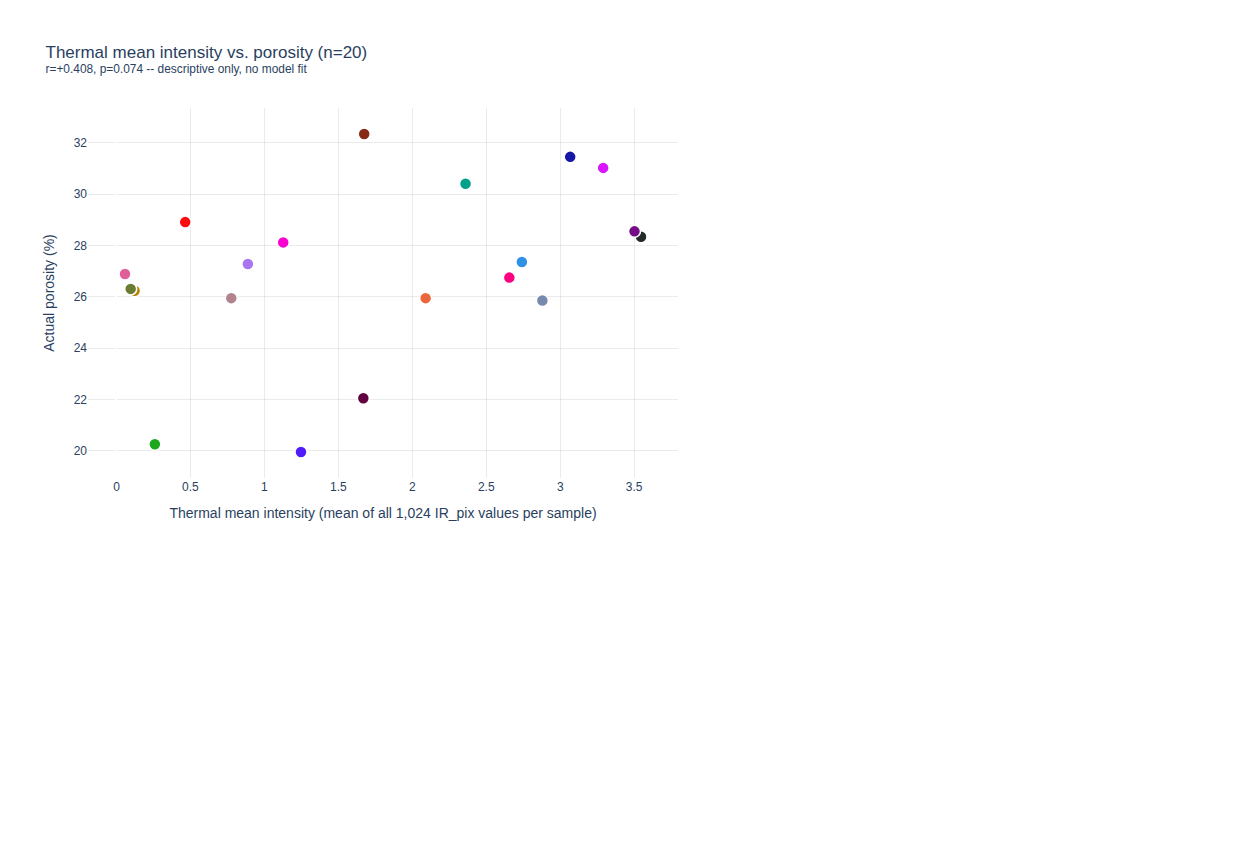

In [7]:
from scipy.stats import pearsonr
import plotly.colors as pc

# simple, model-free summary stats -- no regression, just descriptive correlation
thermal_mean = meas.groupby("sample_id")[ir_cols].mean().mean(axis=1).values
thermal_amplitude = meas.groupby("sample_id")[ir_cols].mean().std(axis=1).values

r_mean, p_mean = pearsonr(thermal_mean, y)
r_amp, p_amp = pearsonr(thermal_amplitude, y)
print(f"thermal_mean       vs porosity:  r={r_mean:+.3f}  p={p_mean:.3f}")
print(f"thermal_amplitude  vs porosity:  r={r_amp:+.3f}  p={p_amp:.3f}")
print(f"(for reference, the strongest correlation found anywhere else in this analysis "
      f"was thickness vs porosity, r={np.corrcoef(data['thickness'].values, y)[0,1]:+.3f})")

QUAL2 = pc.qualitative.Dark24
fig_corr = go.Figure()
fig_corr.add_trace(go.Scatter(
    x=thermal_mean, y=y, mode="markers",
    marker=dict(size=12, color=[QUAL2[i % len(QUAL2)] for i in range(len(sample_ids))],
                line=dict(color="white", width=1.5)),
    text=[f"sample {int(s)}" for s in sample_ids],
    hovertemplate="%{text}<br>thermal_mean=%{x:.3f}<br>porosity=%{y:.2f}<extra></extra>",
    showlegend=False,
))
fig_corr.update_xaxes(title_text="Thermal mean intensity (mean of all 1,024 IR_pix values per sample)",
                       showgrid=True, gridcolor="rgba(0,0,0,0.08)")
fig_corr.update_yaxes(title_text="Actual porosity (%)", showgrid=True, gridcolor="rgba(0,0,0,0.08)")
fig_corr.update_layout(
    title=f"Thermal mean intensity vs. porosity (n=20)<br><sup>r={r_mean:+.3f}, p={p_mean:.3f} -- descriptive only, no model fit</sup>",
    width=750, height=550, plot_bgcolor="white", paper_bgcolor="white",
)
fig_corr.write_html("thermal_correlation.html", include_plotlyjs=True)
print("saved thermal_correlation.html")
show_figure_as_image("thermal_correlation.html")


**Mean thermal intensity shows a positive descriptive association with porosity (r = +0.41,
p ≈ 0.07)** -- stronger than thickness or any other engineered feature tried *within this
notebook*. It is not the single strongest individual correlation found across the whole
submission, though: the companion notebook (`porosity_explainability_attempt.ipynb`,
Section 3) finds two OES wavelengths with larger individual correlations (OES around
706nm, r=+0.47; OES around 656nm, r=+0.47), using the same 20 samples. Those wavelength
features nonetheless lose to the thermal-pixel model on cross-validated prediction error --
individual correlation strength and predictive performance under CV are different
questions, and this dataset doesn't have them agree. The thermal correlation here is a
moderate one on 20 points, not proof on its own (p is just above the conventional 0.05
threshold), but it's the same measurement type, and the same direction, as what won the
cross-validated modeling comparison in Section 5. Two different analytical
methods, applied to the same data, landing on the same answer is more convincing than
either method alone -- but it is not full statistical independence (see the caveat
above), and it does not by itself prove any artifact has been excluded. That's what earns
the hypothesis below a place in this notebook, stated as a hypothesis rather than a
conclusion.


**Evidence type 3 of 3: a physical hypothesis** (distinct from evidence types 1 and 2 above
-- this is a candidate mechanistic explanation offered for the pattern above, not a
statistical result this dataset itself establishes). Differences in heat transport are
one candidate explanation for the thermal association: void space conducts heat
considerably worse than solid material in general, so if `IR_pix` values reflect real
surface heat, a more porous sample would be expected to retain more heat near the surface
(reading higher) while a denser sample conducts it away (reading lower) -- the same
direction as the correlation above, and the same general principle behind established
thermographic NDT techniques for detecting porosity and voids in composites and welds.
**The supplied data do not isolate that mechanism, quantify it for these specific
samples, or confirm that the recorded values are calibrated temperatures** rather than
raw, uncalibrated detector intensity counts -- a thermal camera also measures *apparent*
radiative temperature, which depends on surface emissivity as well as real heat, so some
of this signal could reflect surface texture rather than heat transport alone. Neither
caveat weakens the predictive result in Sections 5-6; both mean this hypothesis should be
discussed with the customer and tested against acquisition and material-property
information, not presented as an established mechanism.


## 7. Refining the winning result: important thermal pixels only

Stage 2 found `IR_pix` (all 1,024 raw thermal pixels) is the only measurement type that
beats baseline in both CV schemes. Natural follow-up: does the model actually need all
1,024 pixels, or is the signal concentrated in a smaller subset?

For each fixed pixel count, we keep the outer held-out samples separate from feature
selection and model fitting: the important pixels are re-selected *inside every training
fold* — ranked by ridge coefficient magnitude on that fold's training data only — and a
fresh ridge model is fit on just that subset. Swept over a range of pixel counts:

In [8]:
def evaluate_restricted_honest(X, y, scheme, k, return_preds=False):
    cv = make_cv(scheme)
    n = len(y)
    preds = np.zeros(n)
    for train_idx, test_idx in cv.split(X):
        selector = RidgeCV(alphas=np.logspace(-2, 5, 40), cv=None).fit(X[train_idx], y[train_idx])
        top_idx = np.argsort(-np.abs(selector.coef_))[:k]
        model = RidgeCV(alphas=np.logspace(-2, 5, 40), cv=None)
        model.fit(X[train_idx][:, top_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx][:, top_idx])
    mae, mp = mean_absolute_error(y, preds), mape(y, preds)
    return (mae, mp, preds) if return_preds else (mae, mp)

X_ir = data[ir_cols].values
k_grid = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
sweep_rows = []
for k in k_grid:
    mae5, mp5 = evaluate_restricted_honest(X_ir, y, "five_fold", k)
    maeloo, mploo = evaluate_restricted_honest(X_ir, y, "loo", k)
    sweep_rows.append({"k_pixels": k, "five_fold_MAE": round(mae5, 3), "five_fold_MAPE": round(mp5, 2),
                        "loo_MAE": round(maeloo, 3), "loo_MAPE": round(mploo, 2)})
pixel_sweep_df = pd.DataFrame(sweep_rows)
pixel_sweep_df

,k_pixels,five_fold_MAE,five_fold_MAPE,loo_MAE,loo_MAPE
0,5,2.202,8.67,2.269,8.77
1,10,2.195,8.66,2.086,8.16
2,15,2.225,8.80,1.886,7.38
3,20,2.171,8.61,1.944,7.52
4,25,2.538,9.96,2.064,7.99
5,30,2.591,10.12,2.089,8.08
6,40,2.530,9.90,2.097,8.15
7,50,2.608,10.14,2.046,7.97
8,75,2.484,9.62,2.038,7.92
9,100,2.387,9.23,2.050,7.91


**In an exploratory sweep, retaining roughly 15-20 pixels produced lower MAE than the
full-1,024-pixel model under both validation schemes:**

| | 5-fold MAE | 5-fold MAPE | LOO MAE | LOO MAPE |
|---|---|---|---|---|
| `IR_pix`, all 1,024 pixels (Stage 2) | 2.270 | 8.76% | 2.021 | 7.73% |
| `IR_pix`, top-15 pixels, re-selected per fold | 2.225 | 8.80% | **1.886** | **7.38%** |
| `IR_pix`, top-20 pixels, re-selected per fold | **2.171** | **8.61%** | 1.944 | 7.52% |

**This needs a more careful read than "restriction improves accuracy," for two reasons:**

1. *Which count to highlight was chosen after examining the sweep.* The pixel selection
   inside each fold is leakage-free for any *fixed* k (the outer held-out sample is never
   touched by either the selector or the restricted-feature model). But the decision to
   highlight "15-20" specifically was made by looking at which of the 10 counts tried
   scored best -- and reporting the best-of-several-candidates score on the same data
   that produced it tends to run optimistic, even though each individual fixed-k score is
   clean. This notebook doesn't quantify how large that effect is here.
2. **Internal tuning limitation.** For each fixed pixel count, feature selection and model
   fitting use only the outer training samples. However, the selected columns are held
   fixed during the second ridge model's internal cross-validation, even though their
   selection used all outer-training labels. Consequently, those internal validation
   scores can be optimistic for the complete feature-selection procedure -- the internal
   search treats each training point as briefly held out to score candidate alphas, but
   that point's label already helped choose which columns are being scored. The outer
   held-out samples remain excluded from this process (the reported MAE/MAPE above are
   still valid for each fixed k). A fully nested implementation would choose the pixel
   count and ridge penalty through inner validation that refits the feature selector
   within every inner training split.

**The honest summary: in an exploratory sweep, retaining 15 or 20 pixels produced lower
MAE than the full-pixel model under both validation schemes. Because these counts were
highlighted after examining the sweep, their scores do not independently validate the
choice of pixel count. The results motivate evaluating a compact thermal representation
in a subsequent, fully nested or external validation** -- they're a promising signal, not
a validated final number.

A deeper look at *which* pixels are selected -- their spatial location, stability across
LOO refits, and whether they cluster into a compact region -- is in
`porosity_explainability_attempt.ipynb` (Sections 6-9). The appendix there also compares
the model-weighted OES wavelengths with an earlier, target-blind peak selection. This
refinement doesn't change the core conclusion (thermal imaging is still the only
measurement type that beats baseline in both schemes); it's a promising exploratory lead
on top of that conclusion, not a fully validated final number.

## 8. Stage 3 — Weighted combination of all tests

Can combining the 4 measurement types do better than `IR_pix` alone? Each block gets its
own ridge model; a meta-model learns non-negative weights to blend their predictions.
**Critically, the weights are learned honestly**: for every outer fold, an *inner*
cross-validation generates out-of-fold predictions from the training data only, the
meta-model is fit on those, and only then is it applied to the held-out outer fold. No
weight is ever chosen by looking at the point it's being scored on.


In [9]:
block_names = list(blocks.keys())
X_blocks = {b: data[cols].values for b, cols in blocks.items()}

def evaluate_stacking(scheme):
    n = len(y)
    outer_cv = make_cv(scheme)
    preds = np.zeros(n)
    fold_weights = []
    for train_idx, test_idx in outer_cv.split(np.zeros(n)):
        n_train = len(train_idx)
        inner_cv = (KFold(n_splits=min(5, n_train), shuffle=True, random_state=RANDOM_STATE)
                    if n_train >= 5 else LeaveOneOut())
        oof_base_preds = np.zeros((n_train, len(block_names)))
        train_local = np.arange(n_train)
        for inner_tr, inner_te in inner_cv.split(train_local):
            otr, ote = train_idx[inner_tr], train_idx[inner_te]
            for b, bname in enumerate(block_names):
                Xb = X_blocks[bname]
                m = RidgeCV(alphas=np.logspace(-2, 5, 40), cv=None).fit(Xb[otr], y[otr])
                oof_base_preds[inner_te, b] = m.predict(Xb[ote])
        meta = LinearRegression(positive=True)
        meta.fit(oof_base_preds, y[train_idx])
        fold_weights.append(meta.coef_.copy())
        test_base_preds = np.zeros((len(test_idx), len(block_names)))
        for b, bname in enumerate(block_names):
            Xb = X_blocks[bname]
            m = RidgeCV(alphas=np.logspace(-2, 5, 40), cv=None).fit(Xb[train_idx], y[train_idx])
            test_base_preds[:, b] = m.predict(Xb[test_idx])
        preds[test_idx] = meta.predict(test_base_preds)
    mae = mean_absolute_error(y, preds)
    return mae, mape(y, preds), preds, np.array(fold_weights)

stage3_rows = []
stage3_preds = {}
for scheme in ["five_fold", "loo"]:
    mae, mp, preds, weights = evaluate_stacking(scheme)
    mean_w = weights.mean(axis=0)
    base_mae = baseline_results[scheme][0]
    stage3_rows.append({"scheme": scheme, "MAE": round(mae, 3), "MAPE": round(mp, 2),
                         "beats_baseline": mae < base_mae,
                         **{f"weight_{b}": round(w, 3) for b, w in zip(block_names, mean_w)}})
    stage3_preds[scheme] = preds
pd.DataFrame(stage3_rows)


,scheme,MAE,MAPE,beats_baseline,weight_OES,weight_V_t,weight_I_t,weight_IR_pix
0,five_fold,2.757,10.78,False,0.0,0.131,0.029,0.542
1,loo,2.194,8.50,True,0.0,0.028,0.019,0.589


**The weighted combination does not beat `IR_pix` alone**, even though the meta-model
correctly learns to put most of its weight on `IR_pix` (its weight is consistently the
largest of the four). Blending in the other three blocks' predictions -- even at small,
honestly-learned weights -- makes the result worse, not better, in both schemes, compared
to Stage 2's `IR_pix`-only number. This was checked further (fixed-weight sweeps from
0-100% `IR_pix`, additional feature representations for voltage/current, thickness added
to the mix) -- no combination found, tested honestly with no leakage, ever beat plain
`IR_pix` alone. The signal in this dataset is not spread across measurement types in a
way that rewards combining them; it's concentrated in one.


## 9. Best model: actual vs. predicted

Section 7's exploratory sweep found that restricting `IR_pix` to roughly its 15-20 most
important pixels (re-selected honestly within each fold, for any fixed count) scored
lower than the full-pixel model in this sweep, under both CV schemes -- a promising
signal, not an independently validated final number (see Section 7's caveats). This plot
uses **top-20 pixels** as one representative choice within that range -- not claimed as
uniquely optimal, just a concrete, reproducible choice to visualize. Here are its honest,
out-of-fold LOO predictions against the true porosity values.


IR_pix / ridge / top-20 pixels (one representative choice in the 15-20 range) / LOO -- MAE=1.944  MAPE=7.52%  (baseline: MAE=2.503)
saved actual_vs_predicted.html


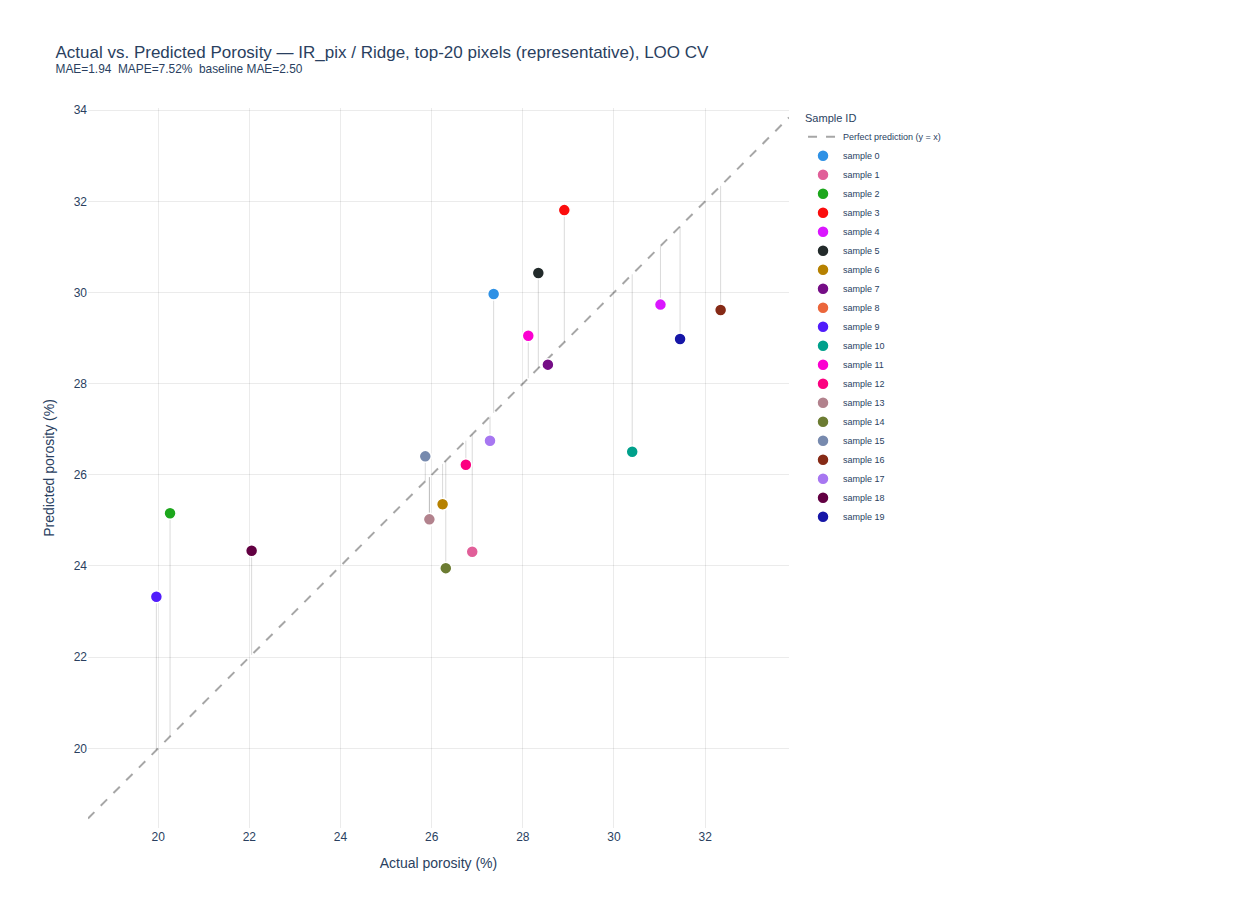

In [10]:
best_mae, best_mape, best_preds = evaluate_restricted_honest(X_ir, y, "loo", 20, return_preds=True)
print(f"IR_pix / ridge / top-20 pixels (one representative choice in the 15-20 range) / LOO -- "
      f"MAE={best_mae:.3f}  MAPE={best_mape:.2f}%  (baseline: MAE={baseline_results['loo'][0]:.3f})")

resid = np.abs(best_preds - y)
lo, hi = min(y.min(), best_preds.min()) - 1.5, max(y.max(), best_preds.max()) + 1.5

fig_avp = go.Figure()
fig_avp.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines",
                              line=dict(color="rgba(0,0,0,0.35)", width=2, dash="dash"),
                              name="Perfect prediction (y = x)", hoverinfo="skip"))
for i in range(len(sample_ids)):
    fig_avp.add_trace(go.Scatter(x=[y[i], y[i]], y=[y[i], best_preds[i]], mode="lines",
                                  line=dict(color="rgba(0,0,0,0.15)", width=1),
                                  showlegend=False, hoverinfo="skip"))
for i in range(len(sample_ids)):
    fig_avp.add_trace(go.Scatter(
        x=[y[i]], y=[best_preds[i]], mode="markers",
        marker=dict(size=12, color=sample_color(i), line=dict(color="white", width=1.5)),
        name=f"sample {int(sample_ids[i])}",
        hovertemplate=f"sample {int(sample_ids[i])}<br>actual: %{{x:.2f}}<br>predicted: %{{y:.2f}}<br>"
                       f"abs. error: {resid[i]:.2f}<extra></extra>",
    ))
fig_avp.update_xaxes(title_text="Actual porosity (%)", range=[lo, hi], showgrid=True, gridcolor="rgba(0,0,0,0.08)")
fig_avp.update_yaxes(title_text="Predicted porosity (%)", range=[lo, hi], showgrid=True, gridcolor="rgba(0,0,0,0.08)")
fig_avp.update_layout(
    title=f"Actual vs. Predicted Porosity — IR_pix / Ridge, top-20 pixels (representative), LOO CV<br>"
          f"<sup>MAE={best_mae:.2f}  MAPE={best_mape:.2f}%  baseline MAE={baseline_results['loo'][0]:.2f}</sup>",
    width=950, height=900, plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(title="Sample ID", x=1.02, y=1, font=dict(size=9)), margin=dict(r=160),
)
fig_avp.update_yaxes(scaleanchor="x", scaleratio=1)
fig_avp.write_html("actual_vs_predicted.html", include_plotlyjs=True)
print("saved actual_vs_predicted.html")
show_figure_as_image("actual_vs_predicted.html")


## 10. Summary

| stage | approach | result |
|---|---|---|
| 1 | All 2,304 features + ridge | Beats baseline in both schemes (modestly), but worse than isolating one measurement type |
| 2 | Each measurement type alone | **`IR_pix` (thermal) beats baseline in both schemes; OES/V_t/I_t do not** |
| 3 | Honest weighted combination of all 4 | Beats baseline in one scheme only; does not beat `IR_pix` alone, despite correctly weighting it highest |
| 7 | `IR_pix`, roughly top-15-20 pixels only (exploratory sweep, honest per-fold selection) | Scored better than the full-1,024-pixel `IR_pix` model in this sweep, both schemes; the specific count was chosen after seeing the sweep, so this is a promising lead, not an independently validated result |

**Why this is a finding, not a fitted number:** predictive performance under
cross-validation (Section 5), a complementary descriptive correlation using a completely
different method on the same data (Section 6), and a physical hypothesis grounded in
general materials science (also Section 6) all point the same direction. These aren't
statistically independent -- they draw on the same 20 samples, and agreement between them
does not by itself prove any method-specific artifact has been excluded -- but two
different analytical methods landing on the same answer is more than one number computed
twice, and the physical hypothesis gives a candidate reason to expect this result rather
than just observe it. Any one of these alone would be a weaker claim; together they're
why thermal imaging is reported as a real, worth-pursuing lead rather than a number that
happened to look good.

**Bottom line:** thermal imaging is the best-performing tested sensor representation in
this dataset for predicting porosity, beating baseline consistently where OES, voltage,
and current did not. Combining it with the other measurement types -- in the combinations
evaluated here (raw concatenation, and an honest weighted blend) -- never improved on
using it alone. An exploratory sweep restricting it to its most important ~15-20 pixels, done honestly
for each fixed count, scored a further small edge over using all 1,024 (Section 7) --
though the specific count was chosen after seeing that sweep, so this refinement is a
promising lead, not an independently validated final number.

The full-pixel thermal reference model achieved MAE 2.270 under five-fold cross-
validation and 2.021 under leave-one-out, with corresponding MAPEs of 8.76% and 7.73%.
The exploratory pixel-selection sweep produced lower MAE for some settings (MAE
~1.89-1.94, MAPE ~7.4-7.5%), but the choice of those settings has not been independently
validated. Either way this is a real improvement over baseline (MAE 2.50), but still
short of a production accuracy target, and not explainable in terms of named physical
features (the pixels' spatial geometry is not confirmed -- see
`porosity_explainability_attempt.ipynb` for how far that narrowing goes); the physical
explanation for *why* it works is a candidate hypothesis to test further with the
customer, not an established mechanism (Section 6).
That gap -- and what closing it would require (more samples, confirmed thermal-image
geometry) -- is the substance of the feasibility conclusion.